# Exercises

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.power as smp
import statsmodels.stats.proportion as smprop
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

## 8.5 Plastic tubes

Some plastic tubes for which the tensile strength is essential are to be produced. Sample tube items are produced and tested where the tensile strength is determined. Two different granules and four possible suppliers are used in the trial. The measurement results (in MPa) are:

| | Granule g1 | Granule g2 |
|---|---|---|
| Supplier a | 34.2 | 33.1 |
| Supplier b | 34.8 | 31.2 |
| Supplier c | 31.3 | 30.2 |
| Supplier d | 31.9 | 31.6 |

The following is run in Python:
```python
D = pd.DataFrame({
    "strength": [34.2, 34.8, 31.3, 31.9, 33.1, 31.2, 30.2, 31.6],
    "supplier": pd.Categorical(["a", "b", "c", "d", "a", "b", "c", "d"]),
    "granule": pd.Categorical([1, 1, 1, 1, 2, 2, 2, 2])
})
fit = smf.ols("strength ~ supplier + granule", data=D).fit()
print(sm.stats.anova_lm(fit))
```
```
          D    sum_sq   mean_sq         F    PR(>F)
supplier  3.0  10.03375  3.344583  3.253749  0.179225
granule   1.0   4.65125  4.651250  4.524929  0.123339
Residual  3.0   3.08375  1.027917       NaN       NaN
```

### a)
Which distribution has been used to find the p-value 0.1792?

**Solution:**

The p-value is calculated using the F-distribution, as shown in the ANOVA table.

$$
    F(3,3) = 3.3445
$$


In [2]:
D = pd.DataFrame({
    "strength": [34.2, 34.8, 31.3, 31.9, 33.1, 31.2, 30.2, 31.6],
    "supplier": pd.Categorical(["a", "b", "c", "d", "a", "b", "c", "d"]),
    "granule": pd.Categorical([1, 1, 1, 1, 2, 2, 2, 2])
})
fit = smf.ols("strength ~ supplier + granule", data=D).fit()
print(sm.stats.anova_lm(fit))

           df    sum_sq   mean_sq         F    PR(>F)
supplier  3.0  10.03375  3.344583  3.253749  0.179225
granule   1.0   4.65125  4.651250  4.524929  0.123339
Residual  3.0   3.08375  1.027917       NaN       NaN


### b)
What is the most correct conclusion based on the analysis among the following options (use $\alpha = 0.05$)?

1) A significant difference has been found between the variances from the analysis of variance
2) A significant difference has been found between the means for the 2 granules but not for the 4 suppliers
3) No significant difference has been found between the means for neither the 4 suppliers nor the 2 granules
4) A significant difference has been found between the means for as well the 4 suppliers as the 2 granules
5) A significant difference has been found between the means for the 4 suppliers but not for the 2 granules

**Solution:**

In [6]:
alpha = 0.05
print(0.179225 > alpha)
print(0.123339 > alpha)

True
True


## 8.6 Joining methods

To compare alternative joining methods and materials, a series of experiments are performed where three different joining methods and four different choices of materials are compared. Data from the experiment are shown in the table below:

| Joining methods | Material 1 | Material 2 | Material 3 | Material 4 | Row average |
|---|---|---|---|---|---|
| A | 242 | 214 | 254 | 248 | 239.50 |
| B | 248 | 214 | 248 | 247 | 239.25 |
| C | 236 | 211 | 245 | 243 | 233.75 |
| **Column average** | **242** | **213** | **249** | **246** | |

In a Python-run for two-way analysis of variance:
```python
D = pd.DataFrame({
    "Strength": [242, 214, 254, 248, 248, 214, 248, 247, 236, 211, 245, 243],
    "Joiningmethod": pd.Categorical(["A","A","A","A","B","B","B","B","C","C","C","C"]),
    "Material": pd.Categorical([1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4])
})
fit = smf.ols("Strength ~ Joiningmethod + Material", data=D).fit()
print(sm.stats.anova_lm(fit))
```
the following output is generated (some values replaced by A, B, C, D, E, F):
```
                    DF    sum_sq   mean_sq    F_val      PR(>F)
Joiningmethod       A      84.5        B           C  0.05041
Material            D         E   825.00           F  1.637e-05
Residuals           6      49.5      8.25
```

### a)
What are the values for A, B and C?

**Solution:**

Using formula's and calculator:

$$
    A = k-1 = 3-1 = 2
$$

$$
    B = MS(tr) = \frac{SS(tr)}{k-1} = \frac{84.5}{2} = 42.25 
$$

$$
    C = F_{tr} = \frac{MS(tr)}{MSE} = \frac{42.25}{8.25} = 5.12
$$

In [ ]:

D = pd.DataFrame({
    "Strength": [242, 214, 254, 248, 248, 214, 248, 247, 236, 211, 245, 243],
    "Joiningmethod": pd.Categorical(["A","A","A","A","B","B","B","B","C","C","C","C"]),
    "Material": pd.Categorical([1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4])
})
fit = smf.ols("Strength ~ Joiningmethod + Material", data=D).fit()
print(sm.stats.anova_lm(fit))

                df  sum_sq  mean_sq           F    PR(>F)
Joiningmethod  2.0    84.5    42.25    5.121212  0.050408
Material       3.0  2475.0   825.00  100.000000  0.000016
Residual       6.0    49.5     8.25         NaN       NaN


### b)
What are the conclusions concerning the importance of the two factors in the experiment (using the usual level $\alpha = 5\%$)?

**Solution:**

At $\alpha = 0.05$: material has a highly significant effect on strength (p $= 1.6 \times 10^{-5}$),

while joining method is not significant (p $= 0.050 > 0.05$).

### c)
Do post hoc analysis for as well the Materials as Joining methods (confidence intervals for pairwise differences and/or hypothesis tests for those differences).

**Solution:**

In [9]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print(pairwise_tukeyhsd(endog=D['Strength'], groups=D['Material'], alpha=0.05))
print(pairwise_tukeyhsd(endog=D['Strength'], groups=D['Joiningmethod'], alpha=0.05))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
     1      2    -29.0 0.0001 -39.7012 -18.2988   True
     1      3      7.0 0.2333  -3.7012  17.7012  False
     1      4      4.0 0.6453  -6.7012  14.7012  False
     2      3     36.0    0.0  25.2988  46.7012   True
     2      4     33.0    0.0  22.2988  43.7012   True
     3      4     -3.0 0.8065 -13.7012   7.7012  False
------------------------------------------------------
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B    -0.25 0.9998 -33.3149 32.8149  False
     A      C    -5.75 0.8798 -38.8149 27.3149  False
     B      C     -5.5 0.8893 -38.5649 27.5649  False
-----------------------------------------------------


### d)
Do residual analysis to check for the assumptions of the model:
1. Normality
2. Variance homogeneity

**Solution:**
The Q-Q plot of the residuals shows that the we don't have a normal distribution of the residuals.

The residuals vs fitted plot, 

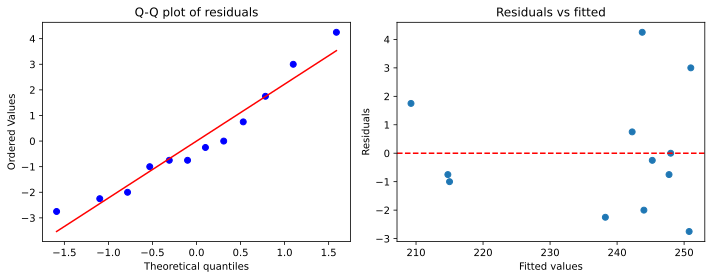

In [10]:
res = fit.resid
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
stats.probplot(res, dist="norm", plot=ax[0])
ax[0].set_title('Q-Q plot of residuals')
ax[1].scatter(fit.fittedvalues, res)
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('Fitted values')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residuals vs fitted')
plt.tight_layout()
plt.show()

## 8.7 Remoulade

A supermarket has just opened a delicacy department wanting to make its own homemade "remoulade" (a Danish delicacy consisting of a certain mixture of pickles and dressing). In order to find the best recipe a taste experiment was conducted. 4 different kinds of dressing and 3 different types of pickles were used in the test. Taste evaluation was carried out on a continuous scale from 0 to 5.

| Pickles type | Dressing A | Dressing B | Dressing C | Dressing D | Row average |
|---|---|---|---|---|---|
| I | 4.0 | 3.0 | 3.8 | 2.4 | 3.30 |
| II | 4.3 | 3.1 | 3.3 | 1.9 | 3.15 |
| III | 3.9 | 2.3 | 3.0 | 2.4 | 2.90 |
| **Column average** | **4.06** | **2.80** | **3.36** | **2.23** | |

In a Python-run for two-way ANOVA:
```python
fit = smf.ols('Taste ~ Pickles + Dressing', data=D).fit()
print(sm.stats.anova_lm(fit))
```

```
            df  sum_sq      mean_sq     F_val   PR(>F)
Pickles.    A   0.326667    0.163333    E       0.287133
Dressing    B   5.536667    1.845556    F       0.002273
Residual    C   D           0.105556    C       D
```

### a)
What are the values of A, B, and C?

**Solution:**

$$
A = k-1 = 3-1 = 2
$$

$$
    B = l-1 = 4-1 = 3
$$

$$
    C = n - k - l + 1 = 12 - 3 - 4 + 1 = 6
$$


### b)
What are the values of D, E, and F?

**Solution:**

$$
 D = SSE = MSE \cdot C = 0.105556 \cdot 6 = 0.6333
$$

$$
    E = F_{tr} = \frac{MS(tr)}{MSE} = \frac{0.163333}{0.105556} = 1.5474 
$$

$$
    F = F_{bl} = \frac{MS(bl)}{MSE} = \frac{1.845556}{0.105556} = 17.4841
$$

### c)
With a test level of $\alpha = 5\%$, what is the conclusion of the tests?

**Solution:**

there's no significant effect of pickles (p $= 0.287 > 0.05$), but a highly significant effect of dressing (p $= 0.002 < 0.05$).

In [11]:
alpha = 0.05

print(0.287133 > alpha)
print(0.002273 > alpha)

True
False


## 8.8 Transport times

In a study the transport delivery times for three transport firms are compared, and the study also involves the size of the transported item. Delivery times in days:

| | Small | Intermediate | Large | Row average |
|---|---|---|---|---|
| Firm A | 1.4 | 2.5 | 2.1 | 2.00 |
| Firm B | 0.8 | 1.8 | 1.9 | 1.50 |
| Firm C | 1.6 | 2.0 | 2.4 | 2.00 |
| **Column average** | **1.27** | **2.10** | **2.13** | |

In Python was run:
```python
fit = smf.ols('Time ~ Firm + Itemsize', data=D).fit()
print(sm.stats.anova_lm(fit))
```
and the following output was obtained (some values replaced by A, B, C, D):
```
          df   sum_sq  mean_sq       F    PR(>F)
Firm       2.0       A        B  4.2857  0.10124
Itemsize   2.0  1.44667        C       D  0.01929
Residual   4.0  0.23333  0.05833
```

### a)
What is A, B, C and D?

**Solution:**

$$
 A = SS_{tr} = MS_{tr} \cdot k-1 = 0.2499 \cdot 2 = 0.4999
$$

$$
 B = MS_{tr} = F_{tr} \cdot MSE = 0.2499
$$

$$
    C = MS_{bl} = \frac{SS_{bl}}{l-1} = \frac{1.44667}{2} = 0.7233
$$

$$
    D = F_{bl} = \frac{MS_{bl}}{MSE} = \frac{0.7233}{0.05833} = 12.4001
$$

### b)
What is the conclusion of the analysis (with a significance level of 5%)?

**Solution:**
there's no significant effect of firm (p $= 0.101 > 0.05$), but a highly significant effect of item size (p $= 0.019 < 0.05$).

In [12]:
alpha = 0.05
print(0.10124 > alpha)
print(0.01929 > alpha)

True
False


## E9.19 Two-way ANOVA sum-constraint

### a)
Find a matrix $T$ such that

$$\tilde{\beta} = T\beta \tag{9-16}$$

with $\tilde{\beta} = [\mu, \alpha_1, ..., \alpha_k, \beta_1, ..., \beta_l]^T$ and $\beta = [\mu, \alpha_1, ..., \alpha_{k-1}, \beta_1, ..., \beta_{l-1}]^T$, such that the constraints (9-270) are fulfilled.

**Solution:**

### b)
Show that the constraints (9-270) can be realized by the design matrix in (9-271). Hint: use the transformation matrix $T$ and the appropriate (non-identifiable) design matrix corresponding to $\tilde{\beta}$.

**Solution:**

## 2025 June Exam — Exercise VIII (Questions 13–14)

A company wants to investigate the effect of lighting and music conditions on employee productivity (measured in the number of units produced per hour).

Two factors are tested:
1. **Lighting** (Factor A) with two levels: Low and High
2. **Music** (Factor B) with three levels: None, Calm, and Energetic

All combinations are tested, and the employees' average productivity is measured:

| | No Music | Calm Music | Energetic Music |
|---|---|---|---|
| Low Lighting | 20 | 23 | 19 |
| High Lighting | 25 | 27 | 22 |

It is assumed that the model is $Y_{ij} = \mu + \alpha_i + \beta_j + \epsilon_{ij}$, $\epsilon_{ij} \sim N(0, \sigma^2)$, where $\alpha_i$ and $\beta_j$ represent the effects of Lighting (Light) and Music (Music). The following result was obtained from Python:

```python
fit = smf.ols('y ~ Light + Music', data=D).fit()
sm.stats.anova_lm(fit)
```
```
          df     sum_sq    mean_sq          F    PR(>F)
Light    1.0  24.000000  24.000000  48.000000  0.020204
Music    2.0  20.333333  10.166667  20.333333  0.046875
Residual 2.0   1.000000   0.500000        NaN       NaN
```

### Question 13 (VIII.1)
What is the conclusion from the relevant statistical tests, using a significance level of $\alpha = 0.05$?

1) There is a significant difference in productivity both with respect to different lighting and different music.
2) There is a significant difference in productivity with respect to different lighting, but not with respect to different music.
3) There is a significant difference in productivity with respect to different music, but not with respect to different lighting.
4) There is no significant difference in productivity, either with respect to different music or different lighting.
5) There is a significant difference in productivity with respect to different music, but one cannot conclude whether there is an effect of different lighting, since there are only two levels.

**Solution:**

since both p-values are less than 0.05, there is a significant difference in productivity **BOTH** with respect to different lighting and different music.

### Question 14 (VIII.2)
To perform further investigations on the effect of music, pairwise comparisons of its effects need to be made. While correcting for multiple tests, what is the Least Significant Distance (LSD) for the pairwise comparisons of the effect of music (using a significance level of $\alpha = 0.05$)?

1) 2.5
2) 2.0
3) 1.5
4) 5.4
5) 6.2

**Solution:**

In [ ]:
M = 3
alpha_bonf = 0.05 / M
t_crit = stats.t.ppf(1 - alpha_bonf/2, df=2)

LSD = t_crit * np.sqrt(2 * 0.5 / 2)MSE = 0.5
df_res = 2

for m in [2, 3]:
    t_crit = stats.t.ppf(0.975, df=df_res)
    LSD = t_crit * np.sqrt(2 * MSE / m)
    print(f"m={m}: LSD={LSD:.4f}")
print(f"LSD = {LSD:.4f}")

LSD = 5.4085
